## 1. Import Libraries and Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2.0 Importing Dataset

In [3]:
df = pd.read_excel("Car_Sales.xlsx")

In [4]:
df.head()

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region
0,C_CND_000001,2022-01-02,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÃ‚Â Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown
1,C_CND_000002,2022-01-02,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÃ‚Â Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,6848189,Aurora
2,C_CND_000003,2022-01-02,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,38701-8047,Passenger,7298798,Greenville
3,C_CND_000004,2022-01-02,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,6257557,Pasco
4,C_CND_000005,2022-01-02,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÃ‚Â Overhead Camshaft,Auto,Red,24500,53546-9427,Hatchback,7081483,Janesville


## 2.1 Data Cleaning

In [5]:
print(df.info())       

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23906 entries, 0 to 23905
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Car_id         23906 non-null  object        
 1   Date           23906 non-null  datetime64[ns]
 2   Customer Name  23905 non-null  object        
 3   Gender         23906 non-null  object        
 4   Annual Income  23906 non-null  int64         
 5   Dealer_Name    23906 non-null  object        
 6   Company        23906 non-null  object        
 7   Model          23906 non-null  object        
 8   Engine         23906 non-null  object        
 9   Transmission   23906 non-null  object        
 10  Color          23906 non-null  object        
 11  Price ($)      23906 non-null  int64         
 12  Dealer_No      23906 non-null  object        
 13  Body Style     23906 non-null  object        
 14  Phone          23906 non-null  int64         
 15  Dealer_Region  2390

In [6]:
print(df.describe())

                                Date  Annual Income     Price ($)  \
count                          23906   2.390600e+04  23906.000000   
mean   2023-03-01 14:28:10.822387456   8.308403e+05  28090.247846   
min              2022-01-02 00:00:00   1.008000e+04   1200.000000   
25%              2022-09-20 00:00:00   3.860000e+05  18001.000000   
50%              2023-03-13 00:00:00   7.350000e+05  23000.000000   
75%              2023-09-08 00:00:00   1.175750e+06  34000.000000   
max              2023-12-31 00:00:00   1.120000e+07  85800.000000   
std                              NaN   7.200064e+05  14788.687608   

              Phone  
count  2.390600e+04  
mean   7.497741e+06  
min    6.000101e+06  
25%    6.746495e+06  
50%    7.496198e+06  
75%    8.248146e+06  
max    8.999579e+06  
std    8.674920e+05  


In [7]:
print(df.isnull().sum())

Car_id           0
Date             0
Customer Name    1
Gender           0
Annual Income    0
Dealer_Name      0
Company          0
Model            0
Engine           0
Transmission     0
Color            0
Price ($)        0
Dealer_No        0
Body Style       0
Phone            0
Dealer_Region    0
dtype: int64


In [8]:
df = df.drop_duplicates()

In [9]:
df = df.fillna(df.median(numeric_only=True))

In [10]:
df["Date"] = pd.to_datetime(df["Date"])

In [11]:
df.columns

Index(['Car_id', 'Date', 'Customer Name', 'Gender', 'Annual Income',
       'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color',
       'Price ($)', 'Dealer_No ', 'Body Style', 'Phone', 'Dealer_Region'],
      dtype='object')

## 2.2 Create Calculated Columns

In [12]:
df["Tax_Amount"] = df["Price ($)"] * 0.05

In [13]:
df["Final_Price"] = df["Price ($)"] + df["Tax_Amount"]

In [14]:
df["Date"] = pd.to_datetime(df["Date"])

In [15]:
df["Car_Age"] = 2026 - df["Date"].dt.year

In [16]:
df.head()

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region,Tax_Amount,Final_Price,Car_Age
0,C_CND_000001,2022-01-02,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÃ‚Â Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown,1300.0,27300.0,4
1,C_CND_000002,2022-01-02,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÃ‚Â Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,6848189,Aurora,950.0,19950.0,4
2,C_CND_000003,2022-01-02,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,38701-8047,Passenger,7298798,Greenville,1575.0,33075.0,4
3,C_CND_000004,2022-01-02,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,6257557,Pasco,700.0,14700.0,4
4,C_CND_000005,2022-01-02,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÃ‚Â Overhead Camshaft,Auto,Red,24500,53546-9427,Hatchback,7081483,Janesville,1225.0,25725.0,4


In [17]:
df.describe()

,Date,Annual Income,Price ($),Phone,Tax_Amount,Final_Price,Car_Age
count,23906,2.390600e+04,23906.000000,2.390600e+04,23906.000000,23906.000000,23906.000000
mean,2023-03-01 14:28:10.822387456,8.308403e+05,28090.247846,7.497741e+06,1404.512392,29494.760238,3.445286
min,2022-01-02 00:00:00,1.008000e+04,1200.000000,6.000101e+06,60.000000,1260.000000,3.000000
25%,2022-09-20 00:00:00,3.860000e+05,18001.000000,6.746495e+06,900.050000,18901.050000,3.000000
50%,2023-03-13 00:00:00,7.350000e+05,23000.000000,7.496198e+06,1150.000000,24150.000000,3.000000
75%,2023-09-08 00:00:00,1.175750e+06,34000.000000,8.248146e+06,1700.000000,35700.000000,4.000000
max,2023-12-31 00:00:00,1.120000e+07,85800.000000,8.999579e+06,4290.000000,90090.000000,4.000000
std,NaN,7.200064e+05,14788.687608,8.674920e+05,739.434380,15528.121988,0.497008


In [18]:
df.describe(include="object")

,Car_id,Customer Name,Gender,Dealer_Name,Company,Model,Engine,Transmission,Color,Dealer_No,Body Style,Dealer_Region
count,23906,23905,23906,23906,23906,23906,23906,23906,23906,23906,23906,23906
unique,23906,3021,2,28,30,154,2,2,3,7,5,7
top,C_CND_000001,Thomas,Male,Progressive Shippers Cooperative Association No,Chevrolet,Diamante,DoubleÃ‚Â Overhead Camshaft,Auto,Pale White,85257-3102,SUV,Austin
freq,1,92,18798,1318,1819,418,12571,12571,11256,3814,6374,4135


## 2.3 Correlation Analysis Using a Heatmap

In [19]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=np.number)

numeric_df.head()

,Annual Income,Price ($),Phone,Tax_Amount,Final_Price,Car_Age
0,13500,26000,8264678,1300.0,27300.0,4
1,1480000,19000,6848189,950.0,19950.0,4
2,1035000,31500,7298798,1575.0,33075.0,4
3,13500,14000,6257557,700.0,14700.0,4
4,1465000,24500,7081483,1225.0,25725.0,4


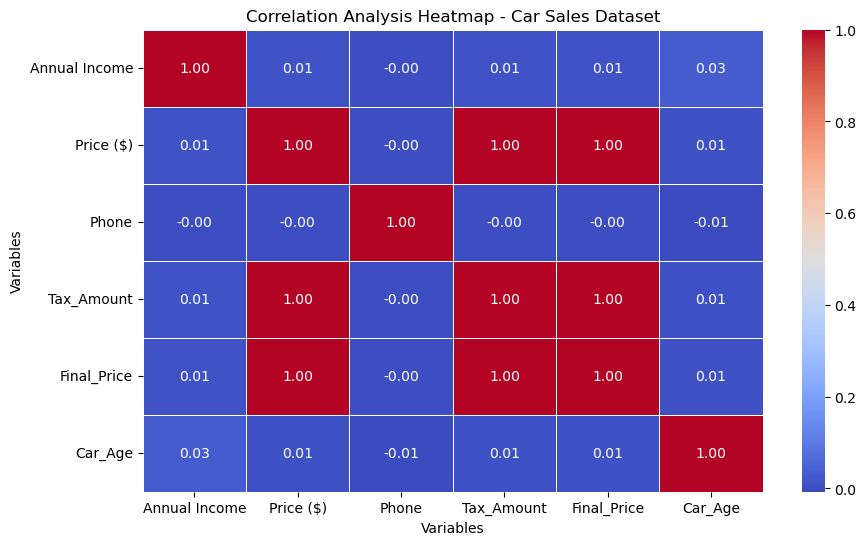

In [20]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical columns
numeric_df = df.select_dtypes(include=np.number)

# Create correlation matrix
corr = numeric_df.corr()

# Plot labelled heatmap
plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,        # shows correlation values
    fmt=".2f",         # decimal format
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Analysis Heatmap - Car Sales Dataset")
plt.xlabel("Variables")
plt.ylabel("Variables")

plt.show()

## 2.4. 5 Sort and Filter Operation

In [21]:
df.sort_values(by="Price ($)", ascending=False).head()

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region,Tax_Amount,Final_Price,Car_Age
7068,C_CND_007069,2022-10-20,Dariel,Male,1388000,Star Enterprises Inc,Cadillac,Eldorado,Overhead Camshaft,Manual,Black,85800,99301-3882,Passenger,6544024,Aurora,4290.00,90090.00,4
17129,C_CND_017130,2023-08-26,Akiva,Male,5046000,Rabun Used Car Sales,Cadillac,Eldorado,Overhead Camshaft,Manual,Black,85601,85257-3102,Passenger,6296288,Austin,4280.05,89881.05,3
13605,C_CND_013606,2023-05-10,Gabriella,Male,1036000,Hatfield Volkswagen,Cadillac,Eldorado,Overhead Camshaft,Manual,Black,85600,99301-3882,Passenger,7918569,Pasco,4280.00,89880.00,3
358,C_CND_000359,2022-02-06,Matthew,Male,1326000,Star Enterprises Inc,Toyota,RAV4,Overhead Camshaft,Manual,Black,85600,99301-3882,Hatchback,8706152,Pasco,4280.00,89880.00,4
9228,C_CND_009229,2022-12-04,Julius,Male,497500,Hatfield Volkswagen,Audi,A6,Overhead Camshaft,Manual,Black,85500,99301-3882,SUV,6621973,Pasco,4275.00,89775.00,4


In [22]:
df.sort_values(by="Price ($)", ascending=True).head()

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region,Tax_Amount,Final_Price,Car_Age
13946,C_CND_013947,2023-05-23,Sajid,Female,13500,Gartner Buick Hyundai Saab,Ford,Taurus,DoubleÃ‚Â Overhead Camshaft,Auto,Black,1200,38701-8047,SUV,7828930,Greenville,60.0,1260.0,3
13996,C_CND_013997,2023-05-25,Amelia,Male,1955000,Rabun Used Car Sales,Mercedes-B,S-Class,DoubleÃ‚Â Overhead Camshaft,Auto,Red,1450,85257-3102,SUV,8719322,Scottsdale,72.5,1522.5,3
14010,C_CND_014011,2023-05-26,Fatima,Male,13500,Ryder Truck Rental and Leasing,Lincoln,Town car,Overhead Camshaft,Manual,Black,1700,06457-3834,Hatchback,7469239,Middletown,85.0,1785.0,3
14020,C_CND_014021,2023-05-26,Oweis,Male,13500,Ryder Truck Rental and Leasing,Mercedes-B,CL500,Overhead Camshaft,Manual,Black,2200,06457-3834,SUV,8583796,Middletown,110.0,2310.0,3
13949,C_CND_013950,2023-05-23,Sammy,Female,680000,McKinney Dodge Chrysler Jeep,Ford,Explorer,DoubleÃ‚Â Overhead Camshaft,Auto,Pale White,4200,85257-3102,Hatchback,8216636,Scottsdale,210.0,4410.0,3


In [23]:
df.sort_values(by="Annual Income", ascending=False).head()

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region,Tax_Amount,Final_Price,Car_Age
14026,C_CND_014027,2023-05-26,Assia,Male,11200000,U-Haul CO,Oldsmobile,Bravada,DoubleÃ‚Â Overhead Camshaft,Auto,Black,26001,78758-7841,Hatchback,6085179,Austin,1300.05,27301.05,3
15675,C_CND_015676,2023-07-10,Sofia,Male,8000000,Motor Vehicle Branch Office,Mercedes-B,S-Class,Overhead Camshaft,Manual,Black,85000,78758-7841,SUV,8315091,Austin,4250.00,89250.00,3
6150,C_CND_006151,2022-09-22,Makayla,Male,7650000,Tri-State Mack Inc,Hyundai,Sonata,Overhead Camshaft,Manual,Pale White,21000,85257-3102,SUV,8246892,Aurora,1050.00,22050.00,4
9996,C_CND_009997,2022-12-17,Peyton,Male,6800000,Progressive Shippers Cooperative Association No,BMW,323i,DoubleÃ‚Â Overhead Camshaft,Auto,Pale White,15000,53546-9427,Hatchback,8787073,Greenville,750.00,15750.00,4
22407,C_CND_022408,2023-12-05,Josh,Male,6600000,Scrivener Performance Engineering,Mercury,Sable,DoubleÃ‚Â Overhead Camshaft,Auto,Red,39000,38701-8047,Sedan,6307543,Aurora,1950.00,40950.00,3


In [24]:
df[df["Price ($)"] > 50000]

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region,Tax_Amount,Final_Price,Car_Age
8,C_CND_000009,2022-01-02,Naomi,Male,815000,Rabun Used Car Sales,Chevrolet,Malibu,Overhead Camshaft,Manual,Pale White,82000,85257-3102,Hardtop,7194857,Pasco,4100.00,86100.00,4
37,C_CND_000038,2022-01-03,Haylee,Male,13500,Gartner Buick Hyundai Saab,Buick,Park Avenue,DoubleÃ‚Â Overhead Camshaft,Auto,Black,61000,38701-8047,Hatchback,7438037,Greenville,3050.00,64050.00,4
65,C_CND_000066,2022-01-04,Annaelle,Male,1650000,Star Enterprises Inc,Buick,Park Avenue,DoubleÃ‚Â Overhead Camshaft,Auto,Black,61000,99301-3882,Hatchback,8380613,Pasco,3050.00,64050.00,4
73,C_CND_000074,2022-01-05,Ingrid,Male,300000,Pitre Buick-Pontiac-Gmc of Scottsdale,Ford,Contour,DoubleÃ‚Â Overhead Camshaft,Auto,Pale White,62000,99301-3882,Sedan,7031644,Pasco,3100.00,65100.00,4
98,C_CND_000099,2022-01-05,Valentina,Female,13500,Iceberg Rentals,Nissan,Maxima,Overhead Camshaft,Manual,Pale White,54000,53546-9427,Sedan,8099375,Scottsdale,2700.00,56700.00,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23839,C_CND_023840,2023-12-30,Sofia,Female,555000,Suburban Ford,Cadillac,Catera,DoubleÃ‚Â Overhead Camshaft,Auto,Pale White,75000,53546-9427,Hatchback,7752902,Janesville,3750.00,78750.00,3
23846,C_CND_023847,2023-12-30,Sylvia,Female,925000,Race Car Help,Oldsmobile,Aurora,Overhead Camshaft,Manual,Red,71000,78758-7841,Passenger,7265067,Austin,3550.00,74550.00,3
23881,C_CND_023882,2023-12-31,Vicky,Male,843000,Star Enterprises Inc,Lexus,LS400,Overhead Camshaft,Manual,Black,69001,99301-3882,Sedan,7011127,Pasco,3450.05,72451.05,3
23895,C_CND_023896,2023-12-31,Sima,Male,965000,Progressive Shippers Cooperative Association No,Mercury,Sable,Overhead Camshaft,Manual,Red,61000,53546-9427,Sedan,8439821,Middletown,3050.00,64050.00,3


In [25]:
df[df["Company"] == "Toyota"]

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region,Tax_Amount,Final_Price,Car_Age
3,C_CND_000004,2022-01-02,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,6257557,Pasco,700.00,14700.00,4
6,C_CND_000007,2022-01-02,Hailey,Male,1600000,Clay Johnson Auto Sales,Toyota,Corolla,Overhead Camshaft,Manual,Pale White,14000,78758-7841,Passenger,7727879,Austin,700.00,14700.00,4
18,C_CND_000019,2022-01-02,Aaliyah,Male,685000,Chrysler Plymouth,Toyota,Land Cruiser,DoubleÃ‚Â Overhead Camshaft,Auto,Pale White,33000,53546-9427,SUV,7627010,Janesville,1650.00,34650.00,4
20,C_CND_000021,2022-01-02,Adrianna,Male,13500,Clay Johnson Auto Sales,Toyota,4Runner,Overhead Camshaft,Manual,Black,25000,78758-7841,Sedan,7889827,Austin,1250.00,26250.00,4
60,C_CND_000061,2022-01-04,Amare,Male,1330000,Ryder Truck Rental and Leasing,Toyota,Tacoma,Overhead Camshaft,Manual,Black,36000,06457-3834,Hardtop,6139882,Janesville,1800.00,37800.00,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23779,C_CND_023780,2023-12-29,Hunter,Male,520000,Rabun Used Car Sales,Toyota,Tacoma,Overhead Camshaft,Manual,Black,36000,85257-3102,Hardtop,8685961,Aurora,1800.00,37800.00,3
23847,C_CND_023848,2023-12-30,Marie Lys,Female,525000,Diehl Motor CO Inc,Toyota,Camry,DoubleÃ‚Â Overhead Camshaft,Auto,Red,31000,06457-3834,Hatchback,7610970,Middletown,1550.00,32550.00,3
23866,C_CND_023867,2023-12-30,Pol,Male,790000,Saab-Belle Dodge,Toyota,Camry,Overhead Camshaft,Manual,Black,29000,60504-7114,Hatchback,7269262,Pasco,1450.00,30450.00,3
23879,C_CND_023880,2023-12-31,Tiffany,Male,380000,Saab-Belle Dodge,Toyota,Land Cruiser,DoubleÃ‚Â Overhead Camshaft,Auto,Black,21001,60504-7114,SUV,8546297,Aurora,1050.05,22051.05,3


In [26]:
df[df["Dealer_Region"] == "Austin"]

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region,Tax_Amount,Final_Price,Car_Age
6,C_CND_000007,2022-01-02,Hailey,Male,1600000,Clay Johnson Auto Sales,Toyota,Corolla,Overhead Camshaft,Manual,Pale White,14000,78758-7841,Passenger,7727879,Austin,700.0,14700.0,4
7,C_CND_000008,2022-01-02,Graham,Male,13500,U-Haul CO,Mitsubishi,Galant,DoubleÃ‚Â Overhead Camshaft,Auto,Pale White,42000,78758-7841,Passenger,6206512,Austin,2100.0,44100.0,4
10,C_CND_000011,2022-01-02,Gregory,Male,13500,Race Car Help,Acura,RL,Overhead Camshaft,Manual,Pale White,31000,78758-7841,SUV,7995489,Austin,1550.0,32550.0,4
20,C_CND_000021,2022-01-02,Adrianna,Male,13500,Clay Johnson Auto Sales,Toyota,4Runner,Overhead Camshaft,Manual,Black,25000,78758-7841,Sedan,7889827,Austin,1250.0,26250.0,4
21,C_CND_000022,2022-01-02,Joshua,Male,2500000,Classic Chevy,Infiniti,I30,DoubleÃ‚Â Overhead Camshaft,Auto,Black,21000,85257-3102,Hardtop,6183219,Austin,1050.0,22050.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23869,C_CND_023870,2023-12-30,Benoit,Male,13500,Suburban Ford,Lincoln,Navigator,DoubleÃ‚Â Overhead Camshaft,Auto,Black,19000,53546-9427,Sedan,8081121,Austin,950.0,19950.0,3
23871,C_CND_023872,2023-12-31,Francesco,Male,801000,Race Car Help,Ford,Explorer,DoubleÃ‚Â Overhead Camshaft,Auto,Pale White,42000,78758-7841,Hatchback,7444561,Austin,2100.0,44100.0,3
23884,C_CND_023885,2023-12-31,Winnie,Male,820500,U-Haul CO,Dodge,Ram Pickup,DoubleÃ‚Â Overhead Camshaft,Auto,Pale White,45500,78758-7841,Hatchback,8519129,Austin,2275.0,47775.0,3
23889,C_CND_023890,2023-12-31,Jeremy,Male,1240000,Rabun Used Car Sales,Dodge,Caravan,DoubleÃ‚Â Overhead Camshaft,Auto,Red,19000,85257-3102,Hardtop,6019604,Austin,950.0,19950.0,3


## 2.5 Index Method and  filter Operation

In [27]:
df.iloc[0:10]

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region,Tax_Amount,Final_Price,Car_Age
0,C_CND_000001,2022-01-02,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÃ‚Â Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown,1300.0,27300.0,4
1,C_CND_000002,2022-01-02,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÃ‚Â Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,6848189,Aurora,950.0,19950.0,4
2,C_CND_000003,2022-01-02,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,38701-8047,Passenger,7298798,Greenville,1575.0,33075.0,4
3,C_CND_000004,2022-01-02,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,6257557,Pasco,700.0,14700.0,4
4,C_CND_000005,2022-01-02,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÃ‚Â Overhead Camshaft,Auto,Red,24500,53546-9427,Hatchback,7081483,Janesville,1225.0,25725.0,4
5,C_CND_000006,2022-01-02,Guadalupe,Male,850000,Classic Chevy,Mitsubishi,Diamante,Overhead Camshaft,Manual,Pale White,12000,85257-3102,Hatchback,7315216,Scottsdale,600.0,12600.0,4
6,C_CND_000007,2022-01-02,Hailey,Male,1600000,Clay Johnson Auto Sales,Toyota,Corolla,Overhead Camshaft,Manual,Pale White,14000,78758-7841,Passenger,7727879,Austin,700.0,14700.0,4
7,C_CND_000008,2022-01-02,Graham,Male,13500,U-Haul CO,Mitsubishi,Galant,DoubleÃ‚Â Overhead Camshaft,Auto,Pale White,42000,78758-7841,Passenger,6206512,Austin,2100.0,44100.0,4
8,C_CND_000009,2022-01-02,Naomi,Male,815000,Rabun Used Car Sales,Chevrolet,Malibu,Overhead Camshaft,Manual,Pale White,82000,85257-3102,Hardtop,7194857,Pasco,4100.0,86100.0,4
9,C_CND_000010,2022-01-02,Grayson,Female,13500,Rabun Used Car Sales,Ford,Escort,DoubleÃ‚Â Overhead Camshaft,Auto,Pale White,15000,85257-3102,Passenger,7836892,Scottsdale,750.0,15750.0,4


In [28]:
df.iloc[0:5, 0:5]

,Car_id,Date,Customer Name,Gender,Annual Income
0,C_CND_000001,2022-01-02,Geraldine,Male,13500
1,C_CND_000002,2022-01-02,Gia,Male,1480000
2,C_CND_000003,2022-01-02,Gianna,Male,1035000
3,C_CND_000004,2022-01-02,Giselle,Male,13500
4,C_CND_000005,2022-01-02,Grace,Male,1465000


In [29]:
df.loc[df["Annual Income"] > 100000]

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region,Tax_Amount,Final_Price,Car_Age
1,C_CND_000002,2022-01-02,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÃ‚Â Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,6848189,Aurora,950.0,19950.0,4
2,C_CND_000003,2022-01-02,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,38701-8047,Passenger,7298798,Greenville,1575.0,33075.0,4
4,C_CND_000005,2022-01-02,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÃ‚Â Overhead Camshaft,Auto,Red,24500,53546-9427,Hatchback,7081483,Janesville,1225.0,25725.0,4
5,C_CND_000006,2022-01-02,Guadalupe,Male,850000,Classic Chevy,Mitsubishi,Diamante,Overhead Camshaft,Manual,Pale White,12000,85257-3102,Hatchback,7315216,Scottsdale,600.0,12600.0,4
6,C_CND_000007,2022-01-02,Hailey,Male,1600000,Clay Johnson Auto Sales,Toyota,Corolla,Overhead Camshaft,Manual,Pale White,14000,78758-7841,Passenger,7727879,Austin,700.0,14700.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23898,C_CND_023899,2023-12-31,Skylar,Male,530000,Rabun Used Car Sales,Volvo,C70,Overhead Camshaft,Manual,Pale White,24000,85257-3102,Hatchback,6225183,Pasco,1200.0,25200.0,3
23900,C_CND_023901,2023-12-31,Nathan,Female,771000,Buddy Storbeck's Diesel Service Inc,Ford,Contour,DoubleÃ‚Â Overhead Camshaft,Auto,Red,19000,06457-3834,Sedan,8170003,Greenville,950.0,19950.0,3
23902,C_CND_023903,2023-12-31,Jimmy,Female,900000,Ryder Truck Rental and Leasing,Chevrolet,Prizm,DoubleÃ‚Â Overhead Camshaft,Auto,Black,16000,06457-3834,Hardtop,7914229,Middletown,800.0,16800.0,3
23903,C_CND_023904,2023-12-31,Emma,Male,705000,Chrysler of Tri-Cities,BMW,328i,Overhead Camshaft,Manual,Red,21000,99301-3882,Sedan,7659127,Scottsdale,1050.0,22050.0,3


In [30]:
df.loc[df["Price ($)"] > 50000]

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region,Tax_Amount,Final_Price,Car_Age
8,C_CND_000009,2022-01-02,Naomi,Male,815000,Rabun Used Car Sales,Chevrolet,Malibu,Overhead Camshaft,Manual,Pale White,82000,85257-3102,Hardtop,7194857,Pasco,4100.00,86100.00,4
37,C_CND_000038,2022-01-03,Haylee,Male,13500,Gartner Buick Hyundai Saab,Buick,Park Avenue,DoubleÃ‚Â Overhead Camshaft,Auto,Black,61000,38701-8047,Hatchback,7438037,Greenville,3050.00,64050.00,4
65,C_CND_000066,2022-01-04,Annaelle,Male,1650000,Star Enterprises Inc,Buick,Park Avenue,DoubleÃ‚Â Overhead Camshaft,Auto,Black,61000,99301-3882,Hatchback,8380613,Pasco,3050.00,64050.00,4
73,C_CND_000074,2022-01-05,Ingrid,Male,300000,Pitre Buick-Pontiac-Gmc of Scottsdale,Ford,Contour,DoubleÃ‚Â Overhead Camshaft,Auto,Pale White,62000,99301-3882,Sedan,7031644,Pasco,3100.00,65100.00,4
98,C_CND_000099,2022-01-05,Valentina,Female,13500,Iceberg Rentals,Nissan,Maxima,Overhead Camshaft,Manual,Pale White,54000,53546-9427,Sedan,8099375,Scottsdale,2700.00,56700.00,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23839,C_CND_023840,2023-12-30,Sofia,Female,555000,Suburban Ford,Cadillac,Catera,DoubleÃ‚Â Overhead Camshaft,Auto,Pale White,75000,53546-9427,Hatchback,7752902,Janesville,3750.00,78750.00,3
23846,C_CND_023847,2023-12-30,Sylvia,Female,925000,Race Car Help,Oldsmobile,Aurora,Overhead Camshaft,Manual,Red,71000,78758-7841,Passenger,7265067,Austin,3550.00,74550.00,3
23881,C_CND_023882,2023-12-31,Vicky,Male,843000,Star Enterprises Inc,Lexus,LS400,Overhead Camshaft,Manual,Black,69001,99301-3882,Sedan,7011127,Pasco,3450.05,72451.05,3
23895,C_CND_023896,2023-12-31,Sima,Male,965000,Progressive Shippers Cooperative Association No,Mercury,Sable,Overhead Camshaft,Manual,Red,61000,53546-9427,Sedan,8439821,Middletown,3050.00,64050.00,3


In [31]:
df.loc[df["Gender"] == "Male"]

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region,Tax_Amount,Final_Price,Car_Age
0,C_CND_000001,2022-01-02,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÃ‚Â Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown,1300.0,27300.0,4
1,C_CND_000002,2022-01-02,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÃ‚Â Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,6848189,Aurora,950.0,19950.0,4
2,C_CND_000003,2022-01-02,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,38701-8047,Passenger,7298798,Greenville,1575.0,33075.0,4
3,C_CND_000004,2022-01-02,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,6257557,Pasco,700.0,14700.0,4
4,C_CND_000005,2022-01-02,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÃ‚Â Overhead Camshaft,Auto,Red,24500,53546-9427,Hatchback,7081483,Janesville,1225.0,25725.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23899,C_CND_023900,2023-12-31,Yuna,Male,13500,U-Haul CO,Buick,Park Avenue,DoubleÃ‚Â Overhead Camshaft,Auto,Pale White,62000,78758-7841,Hatchback,8384785,Aurora,3100.0,65100.0,3
23901,C_CND_023902,2023-12-31,Martin,Male,13500,C & M Motors Inc,Plymouth,Voyager,Overhead Camshaft,Manual,Red,12000,60504-7114,Passenger,8583598,Pasco,600.0,12600.0,3
23903,C_CND_023904,2023-12-31,Emma,Male,705000,Chrysler of Tri-Cities,BMW,328i,Overhead Camshaft,Manual,Red,21000,99301-3882,Sedan,7659127,Scottsdale,1050.0,22050.0,3
23904,C_CND_023905,2023-12-31,Victoire,Male,13500,Chrysler Plymouth,Chevrolet,Metro,DoubleÃ‚Â Overhead Camshaft,Auto,Black,31000,53546-9427,Passenger,6030764,Austin,1550.0,32550.0,3


In [32]:
df.loc[df["Company"] == "Toyota"]

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region,Tax_Amount,Final_Price,Car_Age
3,C_CND_000004,2022-01-02,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,6257557,Pasco,700.00,14700.00,4
6,C_CND_000007,2022-01-02,Hailey,Male,1600000,Clay Johnson Auto Sales,Toyota,Corolla,Overhead Camshaft,Manual,Pale White,14000,78758-7841,Passenger,7727879,Austin,700.00,14700.00,4
18,C_CND_000019,2022-01-02,Aaliyah,Male,685000,Chrysler Plymouth,Toyota,Land Cruiser,DoubleÃ‚Â Overhead Camshaft,Auto,Pale White,33000,53546-9427,SUV,7627010,Janesville,1650.00,34650.00,4
20,C_CND_000021,2022-01-02,Adrianna,Male,13500,Clay Johnson Auto Sales,Toyota,4Runner,Overhead Camshaft,Manual,Black,25000,78758-7841,Sedan,7889827,Austin,1250.00,26250.00,4
60,C_CND_000061,2022-01-04,Amare,Male,1330000,Ryder Truck Rental and Leasing,Toyota,Tacoma,Overhead Camshaft,Manual,Black,36000,06457-3834,Hardtop,6139882,Janesville,1800.00,37800.00,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23779,C_CND_023780,2023-12-29,Hunter,Male,520000,Rabun Used Car Sales,Toyota,Tacoma,Overhead Camshaft,Manual,Black,36000,85257-3102,Hardtop,8685961,Aurora,1800.00,37800.00,3
23847,C_CND_023848,2023-12-30,Marie Lys,Female,525000,Diehl Motor CO Inc,Toyota,Camry,DoubleÃ‚Â Overhead Camshaft,Auto,Red,31000,06457-3834,Hatchback,7610970,Middletown,1550.00,32550.00,3
23866,C_CND_023867,2023-12-30,Pol,Male,790000,Saab-Belle Dodge,Toyota,Camry,Overhead Camshaft,Manual,Black,29000,60504-7114,Hatchback,7269262,Pasco,1450.00,30450.00,3
23879,C_CND_023880,2023-12-31,Tiffany,Male,380000,Saab-Belle Dodge,Toyota,Land Cruiser,DoubleÃ‚Â Overhead Camshaft,Auto,Black,21001,60504-7114,SUV,8546297,Aurora,1050.05,22051.05,3


In [33]:
df.loc[df["Dealer_Region"] == "Austin"]

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region,Tax_Amount,Final_Price,Car_Age
6,C_CND_000007,2022-01-02,Hailey,Male,1600000,Clay Johnson Auto Sales,Toyota,Corolla,Overhead Camshaft,Manual,Pale White,14000,78758-7841,Passenger,7727879,Austin,700.0,14700.0,4
7,C_CND_000008,2022-01-02,Graham,Male,13500,U-Haul CO,Mitsubishi,Galant,DoubleÃ‚Â Overhead Camshaft,Auto,Pale White,42000,78758-7841,Passenger,6206512,Austin,2100.0,44100.0,4
10,C_CND_000011,2022-01-02,Gregory,Male,13500,Race Car Help,Acura,RL,Overhead Camshaft,Manual,Pale White,31000,78758-7841,SUV,7995489,Austin,1550.0,32550.0,4
20,C_CND_000021,2022-01-02,Adrianna,Male,13500,Clay Johnson Auto Sales,Toyota,4Runner,Overhead Camshaft,Manual,Black,25000,78758-7841,Sedan,7889827,Austin,1250.0,26250.0,4
21,C_CND_000022,2022-01-02,Joshua,Male,2500000,Classic Chevy,Infiniti,I30,DoubleÃ‚Â Overhead Camshaft,Auto,Black,21000,85257-3102,Hardtop,6183219,Austin,1050.0,22050.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23869,C_CND_023870,2023-12-30,Benoit,Male,13500,Suburban Ford,Lincoln,Navigator,DoubleÃ‚Â Overhead Camshaft,Auto,Black,19000,53546-9427,Sedan,8081121,Austin,950.0,19950.0,3
23871,C_CND_023872,2023-12-31,Francesco,Male,801000,Race Car Help,Ford,Explorer,DoubleÃ‚Â Overhead Camshaft,Auto,Pale White,42000,78758-7841,Hatchback,7444561,Austin,2100.0,44100.0,3
23884,C_CND_023885,2023-12-31,Winnie,Male,820500,U-Haul CO,Dodge,Ram Pickup,DoubleÃ‚Â Overhead Camshaft,Auto,Pale White,45500,78758-7841,Hatchback,8519129,Austin,2275.0,47775.0,3
23889,C_CND_023890,2023-12-31,Jeremy,Male,1240000,Rabun Used Car Sales,Dodge,Caravan,DoubleÃ‚Â Overhead Camshaft,Auto,Red,19000,85257-3102,Hardtop,6019604,Austin,950.0,19950.0,3


## 2.6 Dashboard Showing 6 Visuals

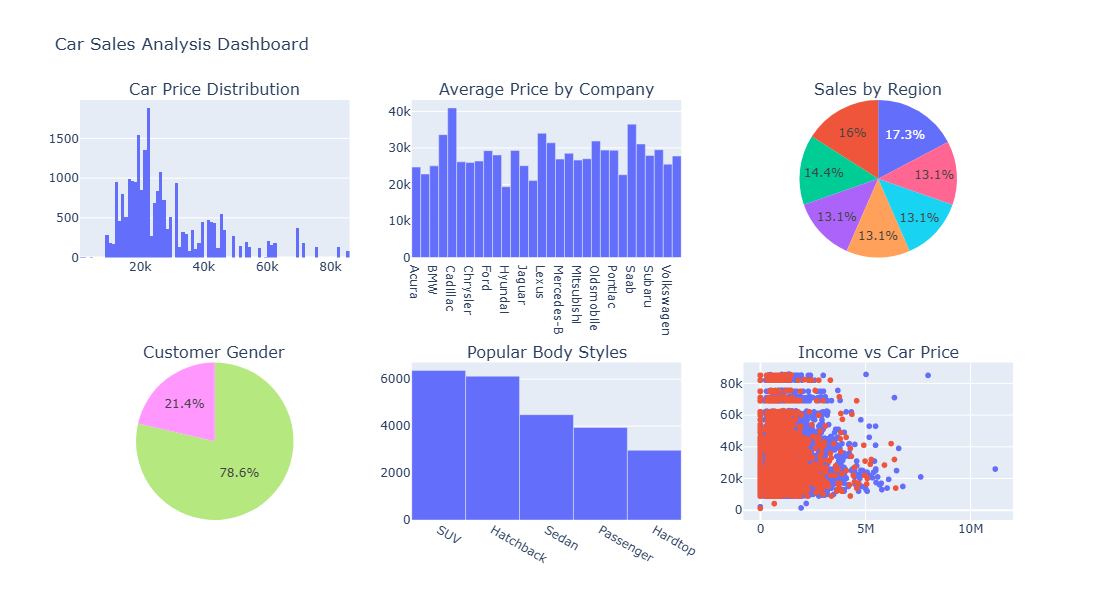

In [34]:
from plotly.subplots import make_subplots
import plotly.express as px

# Create dashboard layout
dashboard = make_subplots(
    rows=2,
    cols=3,
    specs=[
        [{"type":"xy"}, {"type":"xy"}, {"type":"domain"}],
        [{"type":"domain"}, {"type":"xy"}, {"type":"xy"}]
    ],
    subplot_titles=[
        "Car Price Distribution",
        "Average Price by Company",
        "Sales by Region",
        "Customer Gender",
        "Popular Body Styles",
        "Income vs Car Price"
    ]
)

# 1. Price Distribution (Histogram)
fig1 = px.histogram(df, x="Price ($)")

for trace in fig1.data:
    dashboard.add_trace(trace, row=1, col=1)


# 2. Average Price by Company (Bar)
company_price = df.groupby("Company")["Price ($)"].mean().reset_index()

fig2 = px.bar(
    company_price,
    x="Company",
    y="Price ($)"
)

for trace in fig2.data:
    dashboard.add_trace(trace, row=1, col=2)


# 3. Sales by Region (Pie)
fig3 = px.pie(
    df,
    names="Dealer_Region"
)

for trace in fig3.data:
    dashboard.add_trace(trace, row=1, col=3)


# 4. Customer Gender (Pie)
fig4 = px.pie(
    df,
    names="Gender"
)

for trace in fig4.data:
    dashboard.add_trace(trace, row=2, col=1)


# 5. Popular Body Styles (Bar)
body = df["Body Style"].value_counts().reset_index()
body.columns = ["Body Style", "Count"]

fig5 = px.bar(
    body,
    x="Body Style",
    y="Count"
)

for trace in fig5.data:
    dashboard.add_trace(trace, row=2, col=2)


# 6. Annual Income vs Price (Scatter)
fig6 = px.scatter(
    df,
    x="Annual Income",
    y="Price ($)",
    color="Gender"
)

for trace in fig6.data:
    dashboard.add_trace(trace, row=2, col=3)


# Dashboard settings
dashboard.update_layout(
    height=600,
    width=1000,
    title_text="Car Sales Analysis Dashboard",
    showlegend=False
)

dashboard.show()

## 2.7 Descriptive statistics



In [35]:
df.describe()

,Date,Annual Income,Price ($),Phone,Tax_Amount,Final_Price,Car_Age
count,23906,2.390600e+04,23906.000000,2.390600e+04,23906.000000,23906.000000,23906.000000
mean,2023-03-01 14:28:10.822387456,8.308403e+05,28090.247846,7.497741e+06,1404.512392,29494.760238,3.445286
min,2022-01-02 00:00:00,1.008000e+04,1200.000000,6.000101e+06,60.000000,1260.000000,3.000000
25%,2022-09-20 00:00:00,3.860000e+05,18001.000000,6.746495e+06,900.050000,18901.050000,3.000000
50%,2023-03-13 00:00:00,7.350000e+05,23000.000000,7.496198e+06,1150.000000,24150.000000,3.000000
75%,2023-09-08 00:00:00,1.175750e+06,34000.000000,8.248146e+06,1700.000000,35700.000000,4.000000
max,2023-12-31 00:00:00,1.120000e+07,85800.000000,8.999579e+06,4290.000000,90090.000000,4.000000
std,NaN,7.200064e+05,14788.687608,8.674920e+05,739.434380,15528.121988,0.497008


In [36]:
df.describe(include="all")

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region,Tax_Amount,Final_Price,Car_Age
count,23906,23906,23905,23906,2.390600e+04,23906,23906,23906,23906,23906,23906,23906.000000,23906,23906,2.390600e+04,23906,23906.000000,23906.000000,23906.000000
unique,23906,NaN,3021,2,NaN,28,30,154,2,2,3,NaN,7,5,NaN,7,NaN,NaN,NaN
top,C_CND_000001,NaN,Thomas,Male,NaN,Progressive Shippers Cooperative Association No,Chevrolet,Diamante,DoubleÃ‚Â Overhead Camshaft,Auto,Pale White,NaN,85257-3102,SUV,NaN,Austin,NaN,NaN,NaN
freq,1,NaN,92,18798,NaN,1318,1819,418,12571,12571,11256,NaN,3814,6374,NaN,4135,NaN,NaN,NaN
mean,NaN,2023-03-01 14:28:10.822387456,NaN,NaN,8.308403e+05,NaN,NaN,NaN,NaN,NaN,NaN,28090.247846,NaN,NaN,7.497741e+06,NaN,1404.512392,29494.760238,3.445286
min,NaN,2022-01-02 00:00:00,NaN,NaN,1.008000e+04,NaN,NaN,NaN,NaN,NaN,NaN,1200.000000,NaN,NaN,6.000101e+06,NaN,60.000000,1260.000000,3.000000
25%,NaN,2022-09-20 00:00:00,NaN,NaN,3.860000e+05,NaN,NaN,NaN,NaN,NaN,NaN,18001.000000,NaN,NaN,6.746495e+06,NaN,900.050000,18901.050000,3.000000
50%,NaN,2023-03-13 00:00:00,NaN,NaN,7.350000e+05,NaN,NaN,NaN,NaN,NaN,NaN,23000.000000,NaN,NaN,7.496198e+06,NaN,1150.000000,24150.000000,3.000000
75%,NaN,2023-09-08 00:00:00,NaN,NaN,1.175750e+06,NaN,NaN,NaN,NaN,NaN,NaN,34000.000000,NaN,NaN,8.248146e+06,NaN,1700.000000,35700.000000,4.000000
max,NaN,2023-12-31 00:00:00,NaN,NaN,1.120000e+07,NaN,NaN,NaN,NaN,NaN,NaN,85800.000000,NaN,NaN,8.999579e+06,NaN,4290.000000,90090.000000,4.000000


In [37]:
# Average car price
df["Price ($)"].mean()

np.float64(28090.247845729107)

In [38]:
# Highest car price
df["Price ($)"].max()

85800

In [39]:
df["Price ($)"].mean()

np.float64(28090.247845729107)

In [40]:
df["Price ($)"].max()

85800

In [41]:
df["Price ($)"].min()

1200

In [42]:
df["Annual Income"].mean()

np.float64(830840.2851167071)

In [43]:
df["Company"].value_counts()

Company
Chevrolet     1819
Dodge         1671
Ford          1614
Volkswagen    1333
Mercedes-B    1285
Mitsubishi    1277
Chrysler      1120
Oldsmobile    1111
Toyota        1110
Nissan         886
Mercury        874
Lexus          802
Pontiac        796
BMW            790
Volvo          789
Honda          708
Acura          689
Cadillac       652
Plymouth       617
Saturn         586
Lincoln        492
Audi           468
Buick          439
Subaru         405
Jeep           363
Porsche        361
Hyundai        264
Saab           210
Infiniti       195
Jaguar         180
Name: count, dtype: int64

## 3. Logistic Regression Model

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

In [45]:
median_price = df["Price ($)"].median()

df["Expensive"] = np.where(
    df["Price ($)"] > median_price,
    1,
    0
)

In [46]:
df[["Price ($)", "Expensive"]].head()

,Price ($),Expensive
0,26000,1
1,19000,0
2,31500,1
3,14000,0
4,24500,1


In [47]:
X = df[["Annual Income", "Car_Age"]]

y = df["Expensive"]

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [49]:
model = LogisticRegression()

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [50]:
y_pred = model.predict(X_test)

y_pred

array([1, 1, 1, ..., 1, 1, 1], shape=(4782,))

In [51]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.48117942283563364


In [52]:
confusion_matrix(y_test, y_pred)

array([[   0, 2481],
       [   0, 2301]])

In [53]:
# Import libraries
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler


# Create target
median_price = df["Price ($)"].median()

df["Expensive"] = np.where(
    df["Price ($)"] > median_price,
    1,
    0
)


# Select stronger features
X = df[
    [
        "Annual Income",
        "Car_Age",
        "Tax_Amount",
        "Final_Price"
    ]
]

y = df["Expensive"]


# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Scale features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Create model
model = LogisticRegression(
    class_weight="balanced",
    random_state=42
)


# Train
model.fit(X_train, y_train)


# Prediction
y_pred = model.predict(X_test)


# Results
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9983270598076118

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2414
           1       1.00      1.00      1.00      2368

    accuracy                           1.00      4782
   macro avg       1.00      1.00      1.00      4782
weighted avg       1.00      1.00      1.00      4782


Confusion Matrix:
[[2414    0]
 [   8 2360]]


## Summary and Conclusion

This analysis was carried out on the Car Sales dataset to understand key patterns and trends in vehicle sales. The dataset was cleaned by removing duplicate records and handling missing values to improve data quality.

Exploratory Data Analysis (EDA) was performed to examine important features such as car price, company, model, engine type, transmission, and dealer region. Calculated columns were created to generate additional insights, including Tax Amount, Final Price, and Car Age.

Regression concepts were also reviewed. Linear Regression can be used to predict continuous values such as car prices, while Logistic Regression can be used for classification problems such as predicting whether a customer will purchase a vehicle.

The analysis shows how data analytics techniques can help businesses understand customer behaviour, pricing patterns, and sales performance. These insights can support better decision-making in areas such as pricing strategy, inventory management, and customer targeting.